In [1]:
import numpy as np
import matplotlib.pyplot as plt

=== HASIL STUDI KASUS 1 ===
Data Acuan  : T0 = 100.0°C, h0 = 2675.5 kJ/kg | T1 = 150.0°C, h1 = 2693.1 kJ/kg
Hasil Pada Target T = 120.0°C adalah h = 2682.54 kJ/kg


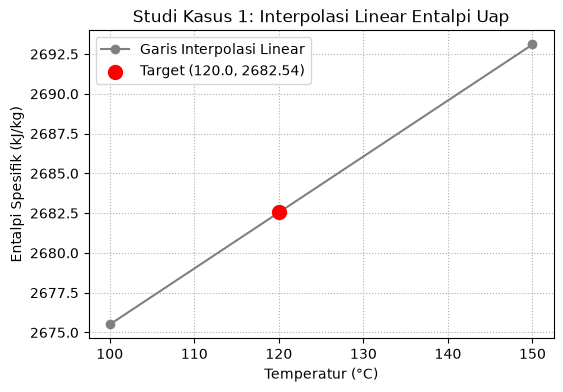

In [2]:
# STUDI KASUS 1: INTERPOLASI LINEAR (Tabel Uap Termodinamika)
# 1. Definisikan Titik Data Acuan
x0, y0 = 100.0, 2675.5
x1, y1 = 150.0, 2693.1

# Nilai temperatur target yang dicari
x_target1 = 120.0

# 2. Rumus Eksplisit Interpolasi Linear
y_pred1 = y0 + ((y1 - y0) / (x1 - x0)) * (x_target1 - x0)

print("=== HASIL STUDI KASUS 1 ===")
print(f"Data Acuan  : T0 = {x0}°C, h0 = {y0} kJ/kg | T1 = {x1}°C, h1 = {y1} kJ/kg")
print(f"Hasil Pada Target T = {x_target1}°C adalah h = {y_pred1:.2f} kJ/kg")

# 3. Visualisasi Grafik Linear
plt.figure(figsize=(6, 4))
plt.plot([x0, x1], [y0, y1], color='gray', linestyle='-', marker='o', label='Garis Interpolasi Linear')
plt.scatter(x_target1, y_pred1, color='red', s=100, zorder=5, label=f'Target ({x_target1}, {y_pred1:.2f})')
plt.title('Studi Kasus 1: Interpolasi Linear Entalpi Uap')
plt.xlabel('Temperatur (°C)')
plt.ylabel('Entalpi Spesifik (kJ/kg)')
plt.grid(True, linestyle=':')
plt.legend()
plt.show()

=== HASIL STUDI KASUS 2 ===
Koefisien Newton: b0 = 200.0, b1 = -6.5, b2 = 0.1125
Estimasi Viskositas pada T = 30.0°C adalah = 123.75 mPa.s


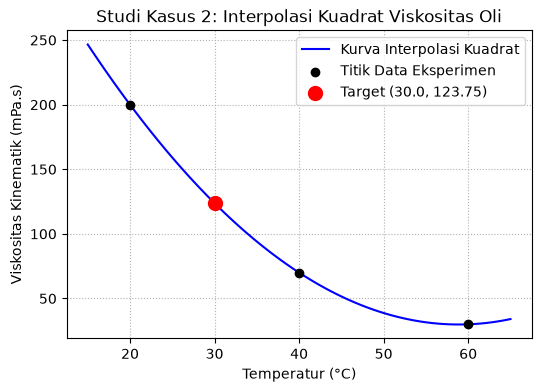

In [3]:
# STUDI KASUS 2: INTERPOLASI KUADRAT (Viskositas Oli Mesin)
# 1. Definisikan Data Acuan (3 Titik)
x_oli = np.array([20.0, 40.0, 60.0])
y_oli = np.array([200.0, 70.0, 30.0])
x_target2 = 30.0

# 2. Hitung Koefisien Polinomial Newton (Divided Differences)
b0 = y_oli[0]
b1 = (y_oli[1] - y_oli[0]) / (x_oli[1] - x_oli[0])

# Komponen pembilang untuk b2 (Gradien Kanan - Gradien Kiri)
gradien_kanan = (y_oli[2] - y_oli[1]) / (x_oli[2] - x_oli[1])
b2 = (gradien_kanan - b1) / (x_oli[2] - x_oli[0])

# 3. Hitung Nilai Prediksi pada Target Orde 2
y_pred2 = b0 + b1*(x_target2 - x_oli[0]) + b2*(x_target2 - x_oli[0])*(x_target2 - x_oli[1])

print("=== HASIL STUDI KASUS 2 ===")
print(f"Koefisien Newton: b0 = {b0}, b1 = {b1}, b2 = {b2}")
print(f"Estimasi Viskositas pada T = {x_target2}°C adalah = {y_pred2:.2f} mPa.s")

# 4. Visualisasi Grafik Kuadrat (Parabola)
x_kurva = np.linspace(15, 65, 100)
# Hitung nilai y pada kurva mulus kontinu
y_kurva = b0 + b1*(x_kurva - x_oli[0]) + b2*(x_kurva - x_oli[0])*(x_kurva - x_oli[1])

plt.figure(figsize=(6, 4))
plt.plot(x_kurva, y_kurva, color='blue', linestyle='-', label='Kurva Interpolasi Kuadrat')
plt.scatter(x_oli, y_oli, color='black', label='Titik Data Eksperimen', zorder=4)
plt.scatter(x_target2, y_pred2, color='red', s=100, zorder=5, label=f'Target ({x_target2}, {y_pred2:.2f})')
plt.title('Studi Kasus 2: Interpolasi Kuadrat Viskositas Oli')
plt.xlabel('Temperatur (°C)')
plt.ylabel('Viskositas Kinematik (mPa.s)')
plt.grid(True, linestyle=':')
plt.legend()
plt.show()

=== HASIL STUDI KASUS 3 ===
Pembobot Lagrange: L0 = 0.15625 | L1 = 0.93750 | L2 = -0.09375
Estimasi Torsi pada 1800.0 RPM adalah = 365.3125 Nm


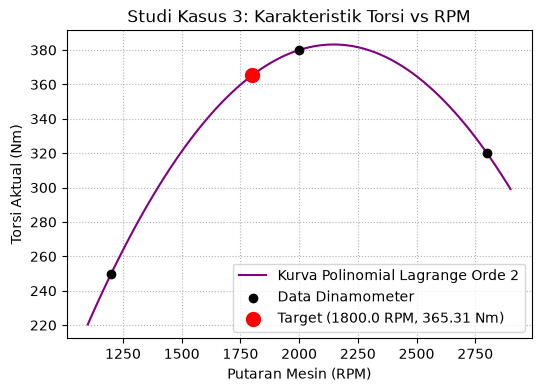

In [4]:
#STUDI KASUS 3: INTERPOLASI POLINOMIAL LAGRANGE (Torsi Mesin Diesel vs RPM)
# 1. Definisikan Data Acuan
x_rpm = np.array([1200.0, 2000.0, 2800.0])
y_torsi = np.array([250.0, 380.0, 320.0])
x_target3 = 1800.0

# 2. Hitung Fungsi Pembobot Lagrange (L_i) secara eksplisit
L0 = ((x_target3 - x_rpm[1]) * (x_target3 - x_rpm[2])) / ((x_rpm[0] - x_rpm[1]) * (x_rpm[0] - x_rpm[2]))
L1 = ((x_target3 - x_rpm[0]) * (x_target3 - x_rpm[2])) / ((x_rpm[1] - x_rpm[0]) * (x_rpm[1] - x_rpm[2]))
L2 = ((x_target3 - x_rpm[0]) * (x_target3 - x_rpm[1])) / ((x_rpm[2] - x_rpm[0]) * (x_rpm[2] - x_rpm[1]))

# 3. Kombinasi Linear Pembobot dengan Nilai Aktual y
y_pred3 = (L0 * y_torsi[0]) + (L1 * y_torsi[1]) + (L2 * y_torsi[2])

print("=== HASIL STUDI KASUS 3 ===")
print(f"Pembobot Lagrange: L0 = {L0:.5f} | L1 = {L1:.5f} | L2 = {L2:.5f}")
print(f"Estimasi Torsi pada {x_target3} RPM adalah = {y_pred3:.4f} Nm")

# 4. Visualisasi Grafik Kasus 3
x_kurva3 = np.linspace(1100, 2900, 100)
# Fungsi polinomial kontinunya
y_kurva3 = (
    (((x_kurva3 - x_rpm[1]) * (x_kurva3 - x_rpm[2])) / ((x_rpm[0] - x_rpm[1]) * (x_rpm[0] - x_rpm[2]))) * y_torsi[0] +
    (((x_kurva3 - x_rpm[0]) * (x_kurva3 - x_rpm[2])) / ((x_rpm[1] - x_rpm[0]) * (x_rpm[1] - x_rpm[2]))) * y_torsi[1] +
    (((x_kurva3 - x_rpm[0]) * (x_kurva3 - x_rpm[1])) / ((x_rpm[2] - x_rpm[0]) * (x_rpm[2] - x_rpm[1]))) * y_torsi[2]
)

plt.figure(figsize=(6, 4))
plt.plot(x_kurva3, y_kurva3, color='purple', linestyle='-', label='Kurva Polinomial Lagrange Orde 2')
plt.scatter(x_rpm, y_torsi, color='black', label='Data Dinamometer', zorder=4)
plt.scatter(x_target3, y_pred3, color='red', s=100, zorder=5, label=f'Target ({x_target3} RPM, {y_pred3:.2f} Nm)')
plt.title('Studi Kasus 3: Karakteristik Torsi vs RPM')
plt.xlabel('Putaran Mesin (RPM)')
plt.ylabel('Torsi Aktual (Nm)')
plt.grid(True, linestyle=':')
plt.legend()
plt.show()

=== HASIL STUDI KASUS 4 ===
Momen Kelengkungan Turunan Kedua: M0 = 0.0, M1 = -4.5, M2 = 0.0


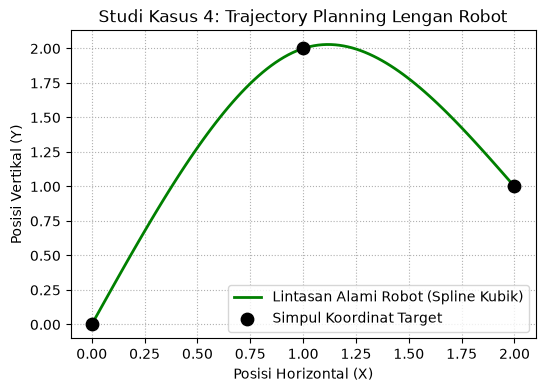

In [5]:
#STUDI KASUS 4: INTERPOLASI NATURAL CUBIC SPLINE (Lintasan Lengan Robot)
# 1. Input Koordinat Geometri Lintasan
x_robot = np.array([0.0, 1.0, 2.0])
y_robot = np.array([0.0, 2.0, 1.0])

# Lebar tiap interval (h_i)
h0 = x_robot[1] - x_robot[0]
h1 = x_robot[2] - x_robot[1]

# 2. Sesuai hitungan matriks simultan pada slide kuliah:
# Kondisi batas alami (Natural Boundary Condition): M0 = 0, M2 = 0
# Persamaan kontinuitas interior menghasilkan: 4*M1 = -18 -> M1 = -4.5
M0 = 0.0
M1 = -4.5
M2 = 0.0
M = np.array([M0, M1, M2])

print("=== HASIL STUDI KASUS 4 ===")
print(f"Momen Kelengkungan Turunan Kedua: M0 = {M[0]}, M1 = {M[1]}, M2 = {M[2]}")

# 3. Fungsi evaluasi lokal Spline Kubik per interval untuk penggambaran grafik kontinu
def evaluasi_spline(x, x_data, y_data, M_data):
    if x <= x_data[1]: # Interval 1 [0, 1]
        h = x_data[1] - x_data[0]
        term1 = (M_data[0] / (6 * h)) * (x_data[1] - x) ** 3
        term2 = (M_data[1] / (6 * h)) * (x - x_data[0]) ** 3
        term3 = (y_data[0] / h - (M_data[0] * h) / 6) * (x_data[1] - x)
        term4 = (y_data[1] / h - (M_data[1] * h) / 6) * (x - x_data[0])
    else: # Interval 2 [1, 2]
        h = x_data[2] - x_data[1]
        term1 = (M_data[1] / (6 * h)) * (x_data[2] - x) ** 3
        term2 = (M_data[2] / (6 * h)) * (x - x_data[1]) ** 3
        term3 = (y_data[1] / h - (M_data[1] * h) / 6) * (x_data[2] - x)
        term4 = (y_data[2] / h - (M_data[2] * h) / 6) * (x - x_data[1])
    return term1 + term2 + term3 + term4

# Generasi titik visualisasi kurva mulus
x_kurva4 = np.linspace(0.0, 2.0, 100)
y_kurva4 = [evaluasi_spline(x, x_robot, y_robot, M) for x in x_kurva4]

# 4. Visualisasi Grafik Lintasan Robot
plt.figure(figsize=(6, 4))
plt.plot(x_kurva4, y_kurva4, color='green', linestyle='-', linewidth=2, label='Lintasan Alami Robot (Spline Kubik)')
plt.scatter(x_robot, y_robot, color='black', s=80, label='Simpul Koordinat Target', zorder=4)
plt.title('Studi Kasus 4: Trajectory Planning Lengan Robot')
plt.xlabel('Posisi Horizontal (X)')
plt.ylabel('Posisi Vertikal (Y)')
plt.grid(True, linestyle=':')
plt.legend()
plt.show()